# Drug Development Landscape
## Part 3: SQL Analysis and Clinical Trial Insights

This notebook explores the normalized clinical trial database through SQL queries to investigate study characteristics, sponsor activity, therapeutic interventions, disease conditions, and other key aspects of the clinical research landscape.

The analysis demonstrates how relational database design enables efficient exploration of complex biomedical datasets and supports evidence-driven insights.

## Import Libraries

In [58]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
connection = sqlite3.connect("../database/drug_development_landscape.db")

In [75]:
pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table';",
    connection
)

,name
0,studies
1,sponsors
2,study_sponsors
3,interventions
4,study_interventions
5,conditions
6,study_conditions
7,locations
8,study_locations


## 1. Total Number of Clinical Studies

In [19]:
pd.read_sql(
    """
    SELECT COUNT(*)
    FROM studies;
    """,
    connection
)

,COUNT(*)
0,5000


### Interpretation

The database contains a total of 5,000 clinical studies extracted from the ClinicalTrials.gov API. This dataset provides a sufficiently large sample to explore trends in clinical research, including sponsor activity, trial phases, therapeutic interventions, and disease indications.

Although the database does not represent all studies available in ClinicalTrials.gov, it is large enough to identify meaningful patterns and demonstrate the capabilities of a relational database for biomedical data analysis.

## 2. Clinical Trial Phase Distribution

In [57]:
phase_counts = pd.read_sql(
    """
SELECT phase AS Phase,
       COUNT(*) AS number_of_studies
FROM studies
WHERE phase IS NOT NULL
GROUP BY phase
ORDER BY number_of_studies DESC;
""",
    connection
)
phase_counts

,Phase,number_of_studies
0,PHASE2,1536
1,PHASE1,1303
2,PHASE3,814
3,PHASE4,678
4,EARLY_PHASE1,102


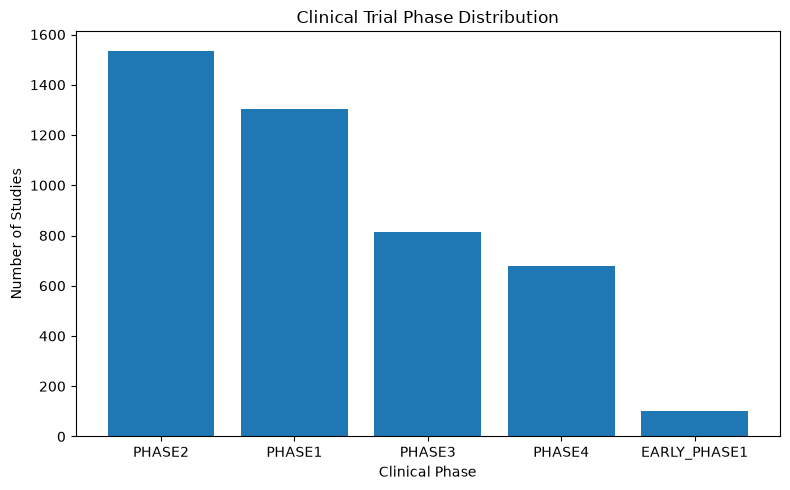

In [67]:
plt.figure(figsize=(8,5))

plt.bar(
    phase_counts["Phase"],
    phase_counts["number_of_studies"]
    
)

plt.title("Clinical Trial Phase Distribution")
plt.xlabel("Clinical Phase")
plt.ylabel("Number of Studies")

plt.tight_layout()

plt.savefig("../figures/clinical_trial_phase_distribution.png", dpi=300)

plt.show()

### Interpretation

Phase II studies represented the largest group in the dataset, followed by Phase I trials. This distribution suggests that a substantial proportion of clinical research focuses on evaluating preliminary efficacy and optimizing treatment protocols before progressing to large confirmatory studies.

As expected, Phase III and Phase IV studies were less frequent, reflecting the increasing costs, complexity, and regulatory requirements associated with later stages of drug development.

## 3. Average Enrollment by Clinical Phase

In [56]:
pd.read_sql(
    """
    SELECT phase AS Phase,
           AVG(enrollment) AS average_enrollment
    FROM studies
    WHERE phase IS NOT NULL
    GROUP BY phase
    ORDER BY average_enrollment DESC;
    """,
    connection
)

,Phase,average_enrollment
0,PHASE3,402.500000
1,PHASE4,216.171852
2,PHASE2,96.479841
3,PHASE1,56.047177
4,EARLY_PHASE1,48.598039


### Interpretation

The average number of participants increased considerably with clinical development stage. Phase III trials enrolled the largest populations, consistent with their objective of confirming efficacy and safety in large patient cohorts before regulatory approval.

Conversely, Phase I and Early Phase I studies involved relatively small populations, reflecting their primary focus on safety, dose escalation, and pharmacokinetic evaluation.

## 4. Most Active Sponsors

In [68]:
top_sponsors = pd.read_sql(
    """
    SELECT sponsors.sponsor_name AS Sponsor,
           COUNT(study_sponsors.study_id) AS number_of_studies
    FROM sponsors
    JOIN study_sponsors
    ON sponsors.sponsor_id = study_sponsors.sponsor_id
    GROUP BY sponsors.sponsor_name
    ORDER BY number_of_studies DESC
    LIMIT 10;
    """,
    connection
)
top_sponsors

,Sponsor,number_of_studies
0,National Cancer Institute (NCI),188
1,GlaxoSmithKline,84
2,Pfizer,83
3,AstraZeneca,81
4,Merck Sharp & Dohme LLC,75
5,Hoffmann-La Roche,63
6,Bristol-Myers Squibb,60
7,Novartis Pharmaceuticals,59
8,Eli Lilly and Company,56
9,Novartis,51


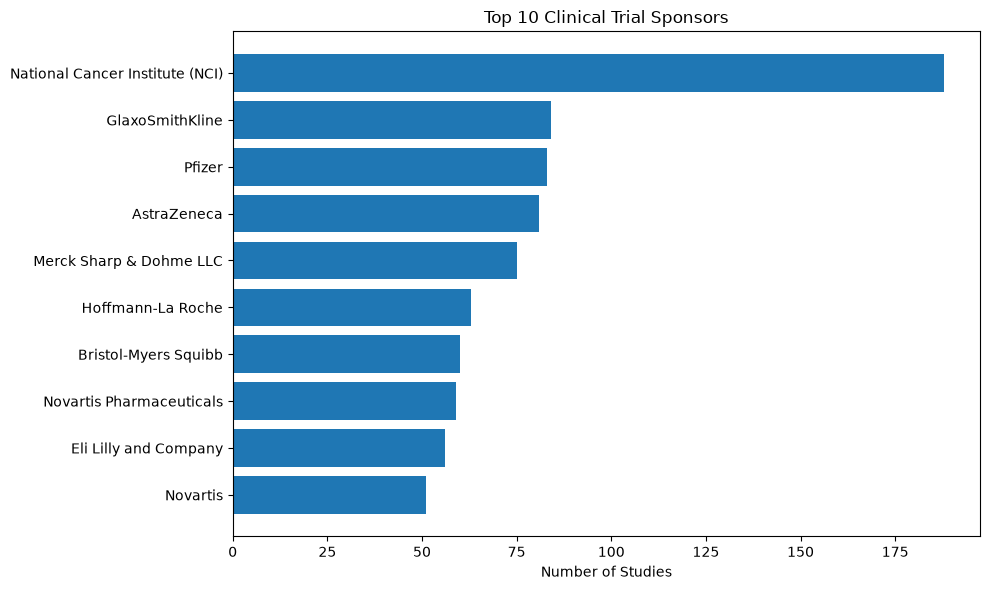

In [70]:
plt.figure(figsize=(10,6))

plt.barh(
    top_sponsors["Sponsor"],
    top_sponsors["number_of_studies"]
)

plt.title("Top 10 Clinical Trial Sponsors")
plt.xlabel("Number of Studies")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig("../figures/top_sponsors.png", dpi=300)

plt.show()

### Interpretation

The National Cancer Institute (NCI) ranked as the most active sponsor in the dataset, followed by several major pharmaceutical companies, including GlaxoSmithKline, Pfizer, AstraZeneca, Merck Sharp & Dohme, and Hoffmann-La Roche.

The presence of both governmental research organizations and large pharmaceutical companies illustrates the collaborative nature of modern clinical research. Minor inconsistencies in sponsor names (for example, "Novartis" and "Novartis Pharmaceuticals") were preserved, reflecting the original records available in ClinicalTrials.gov.

## 5. Most Frequently Investigated Drug Interventions

In [71]:
top_drugs = pd.read_sql(
    """
    SELECT interventions.intervention_name AS Intervention,
           COUNT(*) AS number_of_studies
    FROM interventions
    JOIN study_interventions 
    ON interventions.intervention_id = study_interventions.intervention_id
    WHERE intervention_type = 'DRUG'
        AND LOWER(intervention_name) <> 'placebo'
    GROUP BY interventions.intervention_id
    ORDER BY number_of_studies DESC
  
    LIMIT 10;
    """,
    connection
)
top_drugs

,Intervention,number_of_studies
0,Cyclophosphamide,47
1,Cisplatin,42
2,Bevacizumab,35
3,Carboplatin,33
4,Dexamethasone,32
5,Paclitaxel,31
6,Gemcitabine,30
7,Pembrolizumab,29
8,Metformin,27
9,Docetaxel,26


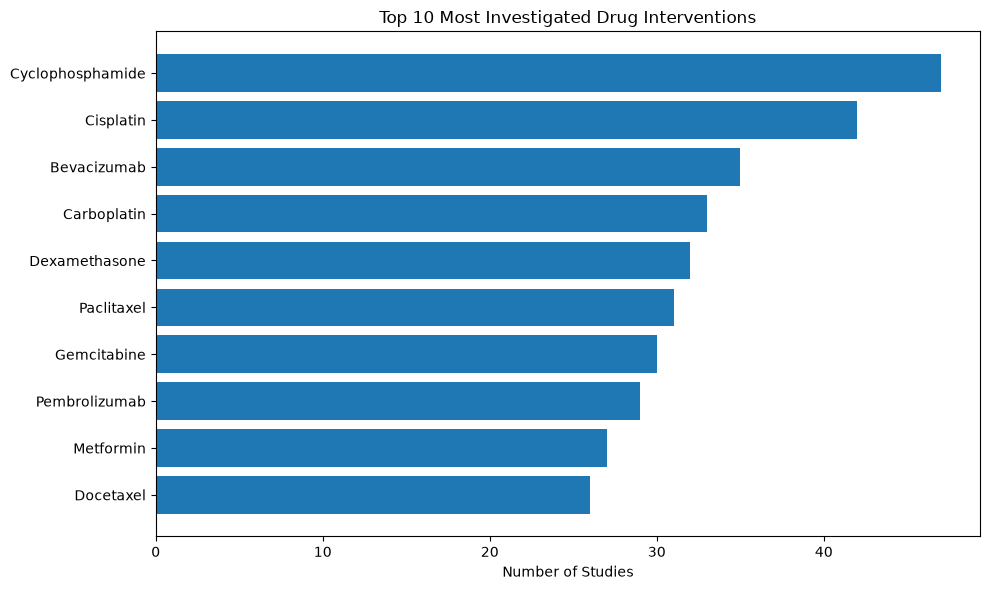

In [73]:
plt.figure(figsize=(10,6))

plt.barh(
    top_drugs["Intervention"],
    top_drugs["number_of_studies"]
)

plt.title("Top 10 Most Investigated Drug Interventions")
plt.xlabel("Number of Studies")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig("../figures/top_drug_interventions.png", dpi=300)

plt.show()

### Interpretation

After excluding placebo interventions, the most frequently investigated drugs included Cyclophosphamide, Cisplatin, Bevacizumab, Carboplatin, Dexamethasone, Paclitaxel, Gemcitabine, Pembrolizumab, Metformin, and Docetaxel.

Most of the highest-ranked drugs are well-established oncology therapies, including chemotherapeutic agents, targeted therapies, and immunotherapies. This pattern suggests that oncology research represents a substantial component of the analyzed clinical trial dataset.

The presence of Metformin among the most frequently investigated drugs also illustrates the diversity of the database, reflecting research beyond oncology and highlighting ongoing studies exploring both established and repurposed medications across multiple therapeutic areas.

Minor inconsistencies in intervention naming (such as differences in capitalization) were preserved to maintain fidelity to the original ClinicalTrials.gov records.


## 6. Sponsors with the Broadest Disease Portfolio

In [52]:
pd.read_sql(
    """
    SELECT sponsors.sponsor_name AS Sponsor,
           COUNT(DISTINCT conditions.condition_id) AS number_of_conditions

    FROM sponsors

    JOIN study_sponsors
    ON  sponsors.sponsor_id = study_sponsors.sponsor_id

    JOIN study_conditions
    ON study_sponsors.study_id = study_conditions.study_id

    JOIN conditions
    ON study_conditions.condition_id = conditions.condition_id

    GROUP BY sponsors.sponsor_name

    ORDER BY number_of_conditions DESC

    LIMIT 10;
    """,
    connection
)


,Sponsor,number_of_conditions
0,National Cancer Institute (NCI),721
1,Merck Sharp & Dohme LLC,129
2,M.D. Anderson Cancer Center,126
3,AstraZeneca,107
4,Pfizer,102
5,Roswell Park Cancer Institute,100
6,Bristol-Myers Squibb,100
7,Fred Hutchinson Cancer Center,78
8,Novartis Pharmaceuticals,76
9,Eli Lilly and Company,76


### Interpretation

This analysis measured the diversity of diseases investigated by each sponsor rather than the total number of studies. Counting distinct conditions provides a broader view of each organization's research portfolio and therapeutic scope.

Sponsors appearing at the top of this ranking are involved in clinical research across a wide range of disease areas, indicating diversified research strategies rather than concentration on a single indication.

## 7. Diseases Most Frequently Investigated with Cyclophosphamide	

In [74]:
pd.read_sql(
    """
    SELECT conditions.condition AS Condition,
    	 COUNT(*) AS cyclophosphamide_studies
    FROM interventions
    
    JOIN study_interventions
    ON interventions.intervention_id = study_interventions.intervention_id
    
    JOIN study_conditions
    ON study_interventions.study_id = study_conditions.study_id
    
    JOIN conditions
    ON study_conditions.condition_id = conditions.condition_id
    
    WHERE interventions.intervention_name= 'Cyclophosphamide'
    GROUP BY conditions.condition
        ORDER BY cyclophosphamide_studies DESC
        LIMIT 10;
    """,
    connection
)

,Condition,cyclophosphamide_studies
0,Multiple Myeloma,3
1,Chronic Lymphocytic Leukemia,3
2,Breast Cancer,3
3,Systemic Lupus Erythematosus,2
4,Primary Effusion Lymphoma,2
5,Lupus Nephritis,2
6,Leukemia,2
7,Anatomic Stage IV Breast Cancer AJCC v8,2
8,Uveal Melanoma,1
9,Unresectable Melanoma,1


### Interpretation

Cyclophosphamide was investigated across a broad range of disease indications, including hematological malignancies, solid tumors, and autoimmune disorders. Multiple Myeloma, Chronic Lymphocytic Leukemia, and Breast Cancer were among the most frequently represented conditions, while Systemic Lupus Erythematosus and Lupus Nephritis also appeared in the top results.

This distribution reflects the long-established clinical role of Cyclophosphamide as both an anticancer agent and an immunosuppressive therapy. Its use across diverse disease areas illustrates how a single drug may have multiple therapeutic applications, making it one of the most versatile medications represented in the dataset.

Because disease names were obtained directly from ClinicalTrials.gov, related conditions may appear under different terminology (for example, "Breast Cancer" and "Anatomic Stage IV Breast Cancer AJCC v8"). These naming differences reflect the original source data and highlight the importance of data standardization in biomedical research.


## Key Findings

The analysis of 5,000 clinical studies retrieved from ClinicalTrials.gov demonstrated how relational databases can be used to explore complex biomedical datasets through SQL. By organizing the information into normalized tables, it was possible to efficiently connect studies, sponsors, interventions, conditions, and study locations using relational queries.

Clinical trial activity was concentrated in Phase II and Phase I studies, while Phase III trials enrolled substantially larger patient populations on average. This pattern reflects the typical progression of drug development, where early-stage studies focus on safety and dose optimization, whereas later phases evaluate efficacy in larger populations.

The analysis also highlighted the prominent role of both public research organizations and the pharmaceutical industry. The National Cancer Institute (NCI) was the most active sponsor in the dataset, while companies such as Pfizer, AstraZeneca, GlaxoSmithKline, and Hoffmann-La Roche were responsible for a large number of clinical studies across multiple therapeutic areas.

Among active drug interventions, Cyclophosphamide was the most frequently investigated medication, followed by Cisplatin, Bevacizumab, Carboplatin, Dexamethasone, and Pembrolizumab. The predominance of established oncology therapies suggests that cancer research represents a substantial component of the analyzed dataset, while the presence of drugs such as Metformin highlights the diversity of therapeutic areas represented.

Finally, the project demonstrated the value of relational database design for biomedical data analysis. By combining multiple normalized tables through SQL joins and aggregate functions, it was possible to answer complex research questions involving sponsors, diseases, and therapeutic interventions. This workflow illustrates how database normalization enables scalable, flexible, and reproducible clinical research analyses.
